
Intensity Transformations and Neighborhood Filtering

230481E
PERERA K.W.A.O.V

Question 1

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


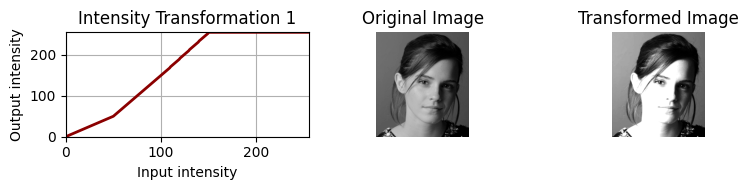

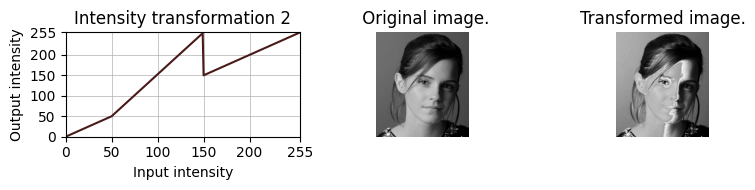

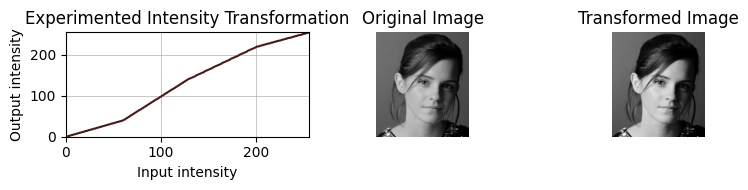

In [97]:
def intensity_transform(im, breakpoints):
    breakpoints = sorted(breakpoints, key=lambda p: p[0]) 
    lut = np.zeros(256, dtype=np.float64)  # lookup table

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        if x1 == x0:
            continue
        xs = np.arange(x0, x1 + 1)
        ys = np.linspace(y0, y1, x1 - x0 + 1)  # linear interpolation
        lut[x0:x1 + 1] = ys

    lut = np.clip(lut, 0, 255).astype(np.uint8)
    transformed = cv2.LUT(im, lut)  # apply mapping
    return transformed, lut
img = cv2.imread('images/images/q1.jpeg', cv2.IMREAD_GRAYSCALE)  # load the image in  grayscale

breakpoints = [[0, 0],[50, 50],[100, 150],[150, 255],[255, 255]]  # transformation
transformed_img, lut = intensity_transform(img, breakpoints)
fig, axes = plt.subplots(1, 3, figsize=(8, 2))

axes[0].plot(np.arange(256), lut, color='darkred', linewidth=2)  # transformation curve
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity Transformation 1')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')  # original
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_img, cmap='gray')  # after transform
axes[2].set_title('Transformed Image')
axes[2].axis('off')
plt.tight_layout()
plt.show()

breakpoints = [[0, 0],[50, 50],[150, 255],[150, 150],[255, 255]] 
lut = np.zeros(256, dtype=np.float64)
for i in range(len(breakpoints) - 1):
    x0, y0 = breakpoints[i]
    x1, y1 = breakpoints[i + 1]
    if x1 == x0:
        continue
    xs = np.arange(x0, x1 + 1)
    ys = np.linspace(y0, y1, x1 - x0 + 1)
    lut[x0:x1 + 1] = ys

lut_uint8 = np.clip(lut, 0, 255).astype(np.uint8)
transformed_img = cv2.LUT(img, lut_uint8)  # apply to image

fig, axes = plt.subplots(1, 3, figsize=(8, 2))

# transformation curve
axes[0].plot(np.arange(256), lut, color='#4a1a1a', linewidth=1.5)
ticks = [0, 50, 100, 150, 200, 255]
axes[0].set_xticks(ticks)
axes[0].set_yticks(ticks)
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation 2')
axes[0].grid(True, linewidth=0.5)
# original image
axes[1].imshow(img, cmap='gray')
axes[1].set_title(' Original image.')
axes[1].axis('off')
# transformed image
axes[2].imshow(transformed_img, cmap='gray')
axes[2].set_title('Transformed image.')
axes[2].axis('off')
plt.tight_layout()
plt.show()
# Experimented Transform
breakpoints = [[0, 0],[60, 40],[128, 140],[200, 220],[255, 255]]  # smooth S-curve
transformed_img, lut = intensity_transform(img, breakpoints)
fig, axes = plt.subplots(1, 3, figsize=(8, 2))

axes[0].plot(np.arange(256), lut, color='#4a1a1a', linewidth=1.5)  # transformation curve
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Experimented Intensity Transformation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True, linewidth=0.5)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(transformed_img, cmap='gray')  # after transform
axes[2].set_title('Transformed Image')
axes[2].axis('off')
plt.tight_layout()
plt.show()


1. The first transformation stretches midtones a lot loosing details in brigher pixels as anything above input 150 gets clipped to pure white..
3. The second sawtooth version with drop at 150 show what a discontinuous breakpoint does, creates a visible seam in the face due to weird jumps in brightness at that point.
4. Final experimented version used a smooth S curve, gives more natural contrast without any jump.
5. Picked S curve as final answer because it stays continuous, no sudden brightness break anywhere.

Question 2


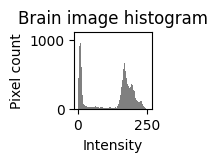

In [73]:
brain_img = cv2.imread('images/images/q2.jpeg', cv2.IMREAD_GRAYSCALE)  # load brain image
plt.figure(figsize=(1, 1))
plt.hist(brain_img.ravel(), bins=256, range=(0, 255), color='gray')  # intensity distribution
plt.xlabel('Intensity')
plt.ylabel('Pixel count')
plt.title('Brain image histogram')
plt.show()

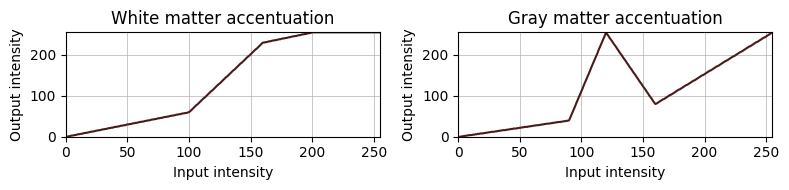

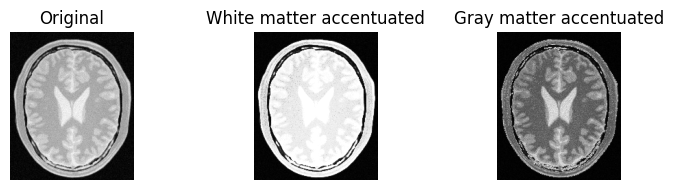

In [96]:
white_matter_bp = [[0, 0],[100, 60],[160, 230],   [200, 255],[255, 255]]
white_matter_img, white_lut = intensity_transform(brain_img, white_matter_bp)
gray_matter_bp = [[0, 0],[90, 40],[120, 255],[160, 80],[255, 255]]
gray_matter_img, gray_lut = intensity_transform(brain_img, gray_matter_bp)
fig, axes = plt.subplots(1, 2, figsize=(8, 2))

axes[0].plot(np.arange(256), white_lut, color='#4a1a1a', linewidth=1.5)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter accentuation')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid(True, linewidth=0.5)

axes[1].plot(np.arange(256), gray_lut, color='#4a1a1a', linewidth=1.5)
axes[1].set_xlabel('Input intensity')
axes[1].set_ylabel('Output intensity')
axes[1].set_title('Gray matter accentuation')
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid(True, linewidth=0.5)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(8, 2))

axes[0].imshow(brain_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(white_matter_img, cmap='gray')
axes[1].set_title('White matter accentuated')
axes[1].axis('off')

axes[2].imshow(gray_matter_img, cmap='gray')
axes[2].set_title('Gray matter accentuated')
axes[2].axis('off')
plt.tight_layout()
plt.show()

Question 3

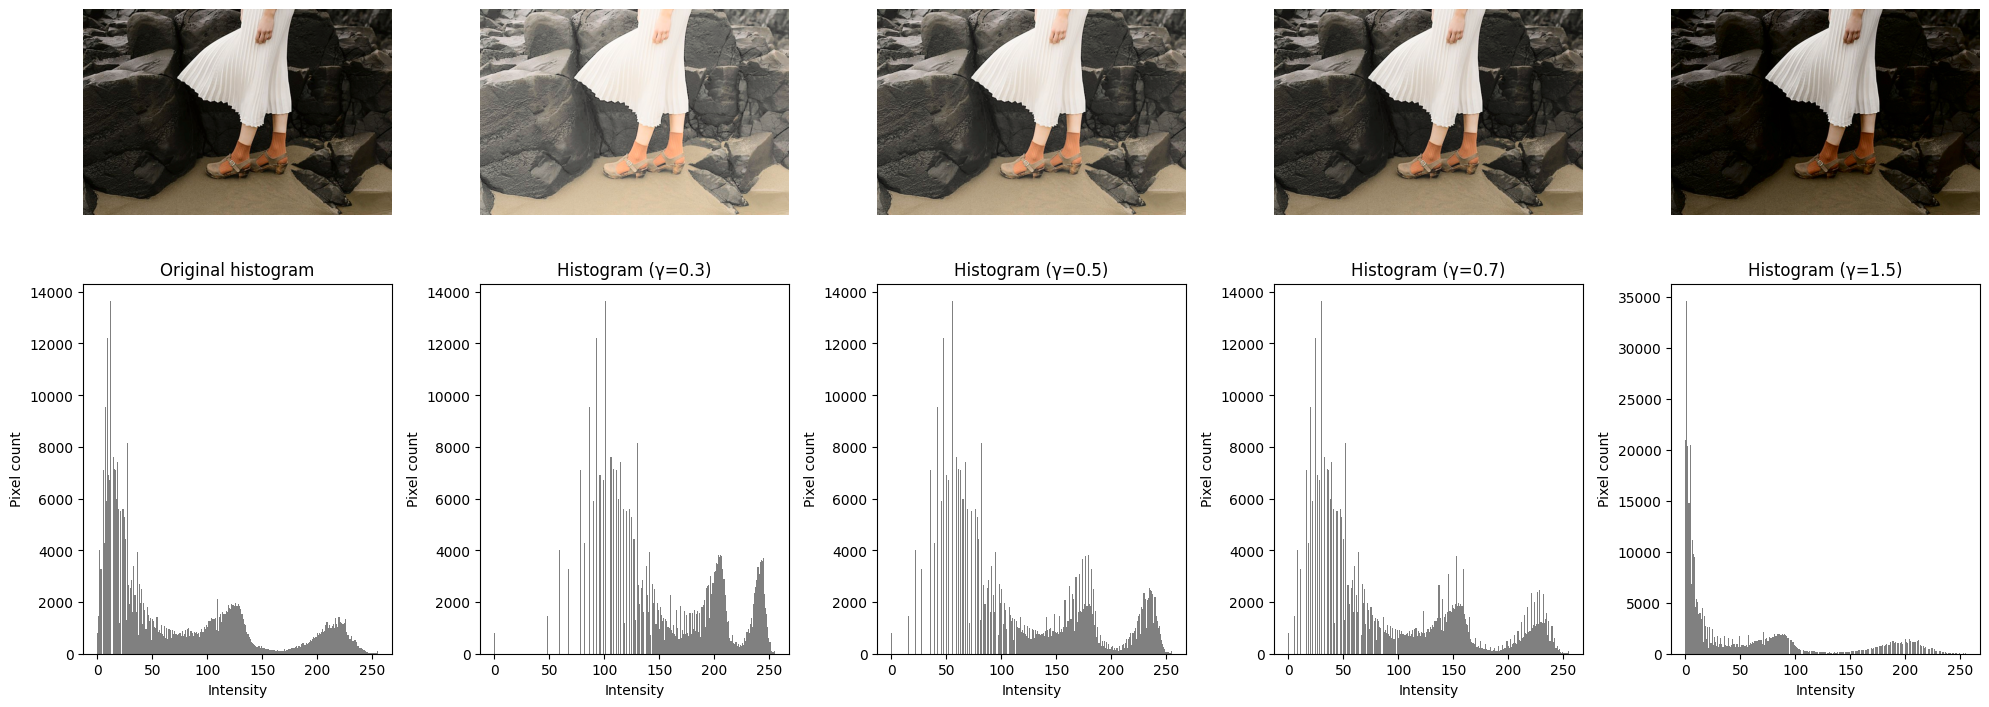

In [95]:
img_gamma = cv2.imread('images/images/image for gamma correction.jpeg')  # BGR by default
img_gamma_rgb = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2RGB)
lab = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2LAB)  # split into L, a, b
L, a, b = cv2.split(lab)

gamma_values = [1, 0.3, 0.5, 0.7, 1.5]  # try several gamma values

def apply_gamma(L, gamma):
    L_norm = L / 255.0  # normalize to [0, 1]
    L_g = np.power(L_norm, gamma)  # apply gamma
    return np.uint8(L_g * 255) 

corrected_images = []  
corrected_L_planes = []  

for gamma in gamma_values:
    L_corrected = apply_gamma(L, gamma)
    lab_corrected = cv2.merge([L_corrected, a, b]) 
    img_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
    img_corrected_rgb = cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB)
    corrected_images.append(img_corrected_rgb)
    corrected_L_planes.append(L_corrected)
n = len(gamma_values)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

# top row: images for each gamma
for i, gamma in enumerate(gamma_values):
    axes[0, i].imshow(corrected_images[i])
    title = 'Original' if gamma == 1 else f'γ = {gamma}'
    axes[0, i].axis('off')
# bottom row: histograms for each gamma
for i, gamma in enumerate(gamma_values):
    axes[1, i].hist(corrected_L_planes[i].ravel(), bins=256, range=(0, 255), color='gray')
    title = 'Original histogram' if gamma == 1 else f'Histogram (γ={gamma})'  # same for histogram
    axes[1, i].set_title(title)
    axes[1, i].set_xlabel('Intensity')
    axes[1, i].set_ylabel('Pixel count')
plt.tight_layout()
plt.show()

1. Applied gamma only on L plane in Lab space so hue and color dont shift, only brightness changes.
2. Tried five gamma values 1, 0.3, 0.5, 0.7, 1.5 to see the range of effect, gamma below 1 brightens shadows, gamma above 1 darkens the image.
3. Since the image has a lot of dark rock and a bright white skirt, a gamma below 1 will help to reveal detail in the shadowed rocks without distorting white fabric.
4. Looking at the histograms, gamma 0.3 pushes almost everything into bright range which looks washed out, gamma 1.5 makes everything dark, so a value around 0.5 or 0.7 looks like the balanced choice.
5. So the choice of gamma is around 0.6



Question 4

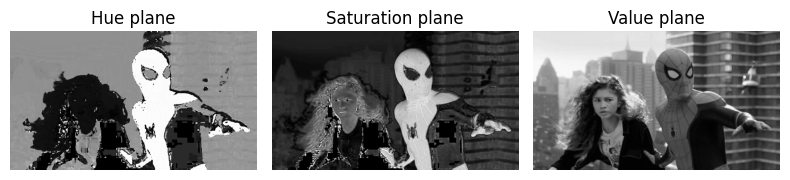

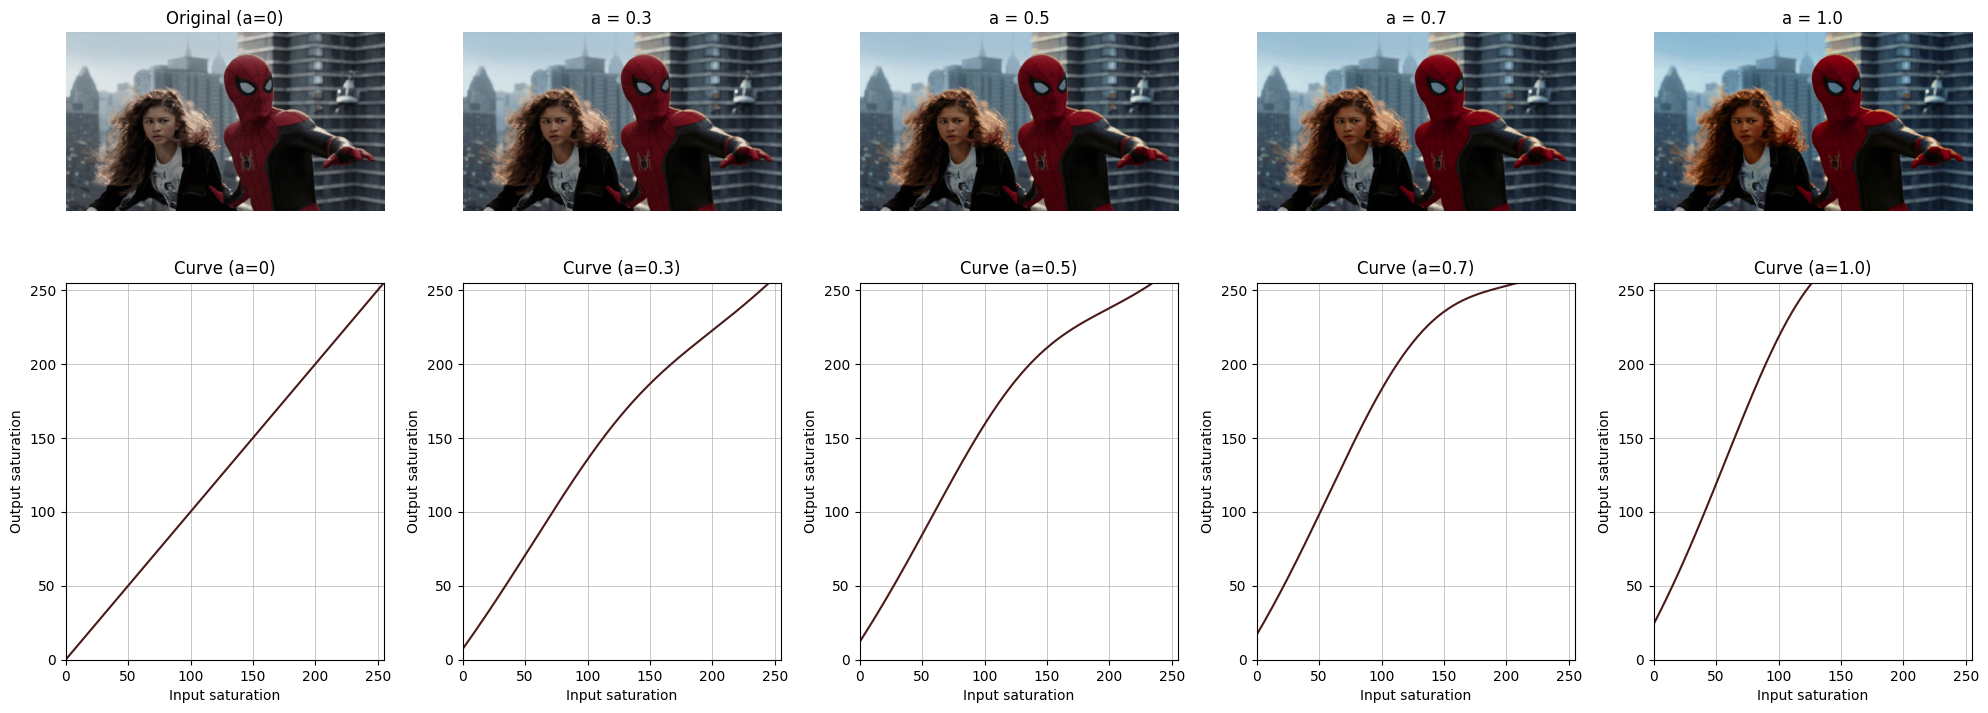

In [94]:
img_vib = cv2.imread('images/images/q4.jpeg')  # BGR 
img_vib_rgb = cv2.cvtColor(img_vib, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img_vib, cv2.COLOR_BGR2HSV)  # convert to HSV
h, s, v = cv2.split(hsv)  # split planes

fig, axes = plt.subplots(1, 3, figsize=(8, 2))
axes[0].imshow(h, cmap='gray')
axes[0].set_title('Hue plane')
axes[0].axis('off')
axes[1].imshow(s, cmap='gray')
axes[1].set_title('Saturation plane')
axes[1].axis('off')
axes[2].imshow(v, cmap='gray')
axes[2].set_title('Value plane')
axes[2].axis('off')
plt.tight_layout()
plt.show()

sigma = 70

def vibrance_transform(x, a, sigma):
    x = x.astype(np.float64)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))  # Gaussian boost
    return np.minimum(x + boost, 255)

a_values = [0, 0.3, 0.5, 0.7, 1.0] 
enhanced_images = []  
curves = []  

for a in a_values:
    s_boosted = vibrance_transform(s, a, sigma).astype(np.uint8)  
    hsv_boosted = cv2.merge([h, s_boosted, v])  # recombine planes
    img_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)  
    img_boosted_rgb = cv2.cvtColor(img_boosted, cv2.COLOR_BGR2RGB)
    enhanced_images.append(img_boosted_rgb)
    x_vals = np.arange(0, 256)
    curves.append(vibrance_transform(x_vals, a, sigma))

n = len(a_values)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
# top row: enhanced images
for i, a in enumerate(a_values):
    axes[0, i].imshow(enhanced_images[i])
    title = 'Original (a=0)' if a == 0 else f'a = {a}' 
    axes[0, i].set_title(title)
    axes[0, i].axis('off')
# bottom row: transformation curves
for i, a in enumerate(a_values):
    axes[1, i].plot(np.arange(256), curves[i], color='#4a1a1a', linewidth=1.5)
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_ylim(0, 255)
    axes[1, i].set_xlabel('Input saturation')
    axes[1, i].set_ylabel('Output saturation')
    axes[1, i].set_title(f'Curve (a={a})')
    axes[1, i].grid(True, linewidth=0.5)
plt.tight_layout()
plt.show()

1. Split into H S V, only S plane goes through the vibrance formula so hue and brightness dont change.
2. Formula boosts mid saturation pixels most since its centered at 128 with sigma 70.
3. a = 0.5 is a starting guess
3. Tested for a = 0, 0.3, 0.5, 0.7, 1.0, higher 'a' gives stronger boost but risks looking oversaturated.
4. Picked 'a' around 0.5 as final since it gives visible color pop without looking fake.

Question 5

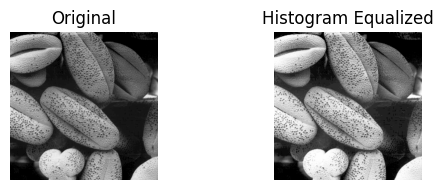

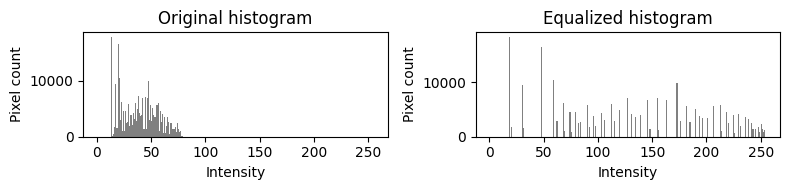

In [93]:
shells_img = cv2.imread('images/images/shells.tif', cv2.IMREAD_GRAYSCALE)  # load as grayscale
def histogram_equalize(im):
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 255))  # pixel count per intensity
    cdf = np.cumsum(hist)  # cumulative sum
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())  # scale to [0, 255]
    lut = cdf_normalized.astype(np.uint8)  # lookup table
    equalized = lut[im]  # map each pixel through the LUT
    return equalized, lut

equalized_img, eq_lut = histogram_equalize(shells_img)
fig, axes = plt.subplots(1, 2, figsize=(6, 2))

axes[0].imshow(shells_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(equalized_img, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 2))

axes[0].hist(shells_img.ravel(), bins=256, range=(0, 255), color='gray')  # before
axes[0].set_title('Original histogram')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Pixel count')

axes[1].hist(equalized_img.ravel(), bins=256, range=(0, 255), color='gray')  # after
axes[1].set_title('Equalized histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Pixel count')
plt.tight_layout()
plt.show()

1. Histogram, cumulative sum, normalization, LUT mapping is implemented manually with np.histogram and np.cumsum, rather than calling cv2.equalizeHist().
2. Original histogram was mostly in dark range, after equalizing it spreads across full range giving more contrast and detail in the shell texture.
3. Equalized histogram looks spiky with gaps, normal since equalization cant create new intensity values, just spreads existing ones.

Question 6

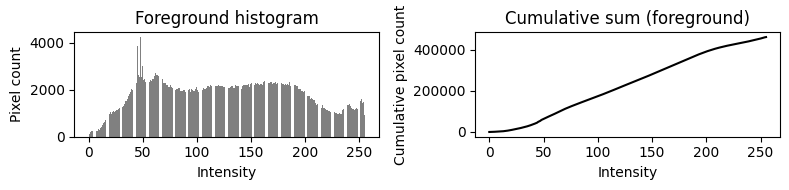

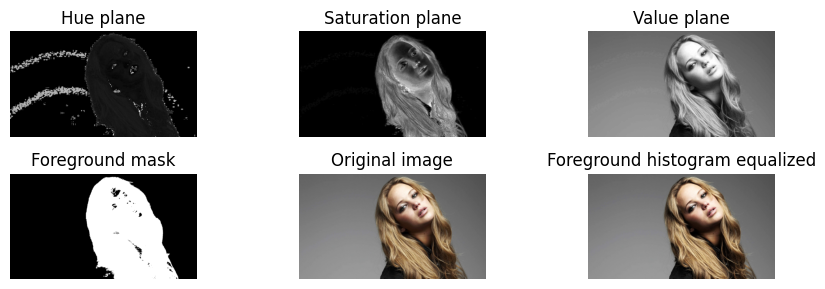

In [98]:
img6 = cv2.imread('images/images/q6.jpeg')  # BGR by default
img6_rgb = cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)

hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)  # convert to HSV
h6, s6, v6 = cv2.split(hsv6)  # split planes
# threshold saturation to get foreground mask
_, mask = cv2.threshold(s6, 25, 255, cv2.THRESH_BINARY)
# extract foreground and compute histogram
foreground = cv2.bitwise_and(v6, v6, mask=mask)
hist_fg, _ = np.histogram(foreground[mask == 255].ravel(), bins=256, range=(0, 255))
# cumulative sum
cdf_fg = np.cumsum(hist_fg)

# histogram equalize the foreground
cdf_min = cdf_fg[cdf_fg > 0].min()
total_fg_pixels = mask[mask == 255].size
eq_lut_fg = np.round((cdf_fg - cdf_min) / (total_fg_pixels - cdf_min) * 255).astype(np.uint8)
eq_lut_fg = np.clip(eq_lut_fg, 0, 255)

foreground_eq = eq_lut_fg[v6]  # apply LUT
foreground_eq = cv2.bitwise_and(foreground_eq, foreground_eq, mask=mask)  # keep only foreground

# extract background and recombine
background_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(v6, v6, mask=background_mask)
combined_v = cv2.add(background, foreground_eq)

hsv_result = cv2.merge([h6, s6, combined_v])
result_bgr = cv2.cvtColor(hsv_result, cv2.COLOR_HSV2BGR)
result_rgb = cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB)

# foreground histogram and its cumulative sum
fig, axes = plt.subplots(1, 2, figsize=(8, 2))
axes[0].bar(np.arange(256), hist_fg, color='gray')
axes[0].set_title('Foreground histogram')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Pixel count')

axes[1].plot(cdf_fg, color='black')
axes[1].set_title('Cumulative sum (foreground)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Cumulative pixel count')
plt.tight_layout()
plt.show()
# display everything else
fig, axes = plt.subplots(2, 3, figsize=(9, 3))

axes[0, 0].imshow(h6, cmap='gray')
axes[0, 0].set_title('Hue plane')
axes[0, 0].axis('off')

axes[0, 1].imshow(s6, cmap='gray')
axes[0, 1].set_title('Saturation plane')
axes[0, 1].axis('off')

axes[0, 2].imshow(v6, cmap='gray')
axes[0, 2].set_title('Value plane')
axes[0, 2].axis('off')

axes[1, 0].imshow(mask, cmap='gray')
axes[1, 0].set_title('Foreground mask')
axes[1, 0].axis('off')

axes[1, 1].imshow(img6_rgb)
axes[1, 1].set_title('Original image')
axes[1, 1].axis('off')

axes[1, 2].imshow(result_rgb)
axes[1, 2].set_title('Foreground histogram equalized')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

1. Saturation plane thresholding is used to get foreground mask since background has low saturation compared to subject.
2. Foreground (person) gains visible contrast and detail after equalization, background stays untouched and smooth.
3. Saturation is a reasonable choice for the mask here since background has low saturation compared to the subject, though may fail if subject has low saturation areas too.

Question 7

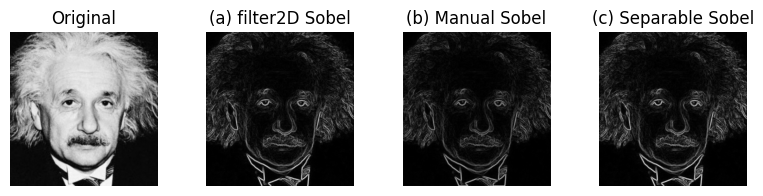

In [99]:
img7 = cv2.imread('images/images/q7.jpeg', cv2.IMREAD_GRAYSCALE) 

sobel_x_kernel = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]], dtype=np.float32)  # horizontal gradient kernel
sobel_y_kernel = sobel_x_kernel.T  # vertical gradient kernel

# (a) Sobel using filter2D
grad_x_2d = cv2.filter2D(img7, cv2.CV_64F, sobel_x_kernel)
grad_y_2d = cv2.filter2D(img7, cv2.CV_64F, sobel_y_kernel)
grad_mag_2d = np.sqrt(grad_x_2d**2 + grad_y_2d**2)
grad_mag_2d = np.uint8(np.clip(grad_mag_2d / grad_mag_2d.max() * 255, 0, 255))

# (b) Sobel filtering written from scratch (manual convolution)
def sobel_manual(im, kernel):
    h, w = im.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')  # zero padding
    output = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]  
            output[i, j] = np.sum(region * kernel)  # convolution sum
    return output

grad_x_manual = sobel_manual(img7.astype(np.float64), sobel_x_kernel)
grad_y_manual = sobel_manual(img7.astype(np.float64), sobel_y_kernel)
grad_mag_manual = np.sqrt(grad_x_manual**2 + grad_y_manual**2)
grad_mag_manual = np.uint8(np.clip(grad_mag_manual / grad_mag_manual.max() * 255, 0, 255))

# (c) Sobel using the separable kernel property
col_kernel = np.array([[1], [2], [1]], dtype=np.float32)  # smoothing (vertical)
row_kernel = np.array([[1, 0, -1]], dtype=np.float32)  # differencing (horizontal)
grad_x_sep = cv2.filter2D(img7, cv2.CV_64F, col_kernel)
grad_x_sep = cv2.filter2D(grad_x_sep, cv2.CV_64F, row_kernel)
grad_y_sep = cv2.filter2D(img7, cv2.CV_64F, row_kernel.T)
grad_y_sep = cv2.filter2D(grad_y_sep, cv2.CV_64F, col_kernel.T) 
grad_mag_sep = np.sqrt(grad_x_sep**2 + grad_y_sep**2)
grad_mag_sep = np.uint8(np.clip(grad_mag_sep / grad_mag_sep.max() * 255, 0, 255))
# display all three side by side, with original
fig, axes = plt.subplots(1, 4, figsize=(8, 2))

axes[0].imshow(img7, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(grad_mag_2d, cmap='gray')
axes[1].set_title('(a) filter2D Sobel')
axes[1].axis('off')

axes[2].imshow(grad_mag_manual, cmap='gray')
axes[2].set_title('(b) Manual Sobel')
axes[2].axis('off')

axes[3].imshow(grad_mag_sep, cmap='gray')
axes[3].set_title('(c) Separable Sobel')
axes[3].axis('off')
plt.tight_layout()
plt.show()

1. Compared filter2D, manual double loop convolution, and separable (column then row) method.
2. All three gave same result visually, expected since mathematically identical operation.
3. Separable method is fastest, two 1D passes instead of one full 2D convolution.
4. Manual loop is slower but shows understanding of what convolution actually does.

Question 8

Normalized SSD (scale factor = 4)
----------------------------------------
im01:  Nearest-neighbor SSD = 0.011778   |   Bilinear SSD = 0.009239
im02:  Nearest-neighbor SSD = 0.002982   |   Bilinear SSD = 0.002259
im03:  Nearest-neighbor SSD = 0.006627   |   Bilinear SSD = 0.005238
im04:  Nearest-neighbor SSD = 0.018911   |   Bilinear SSD = 0.015190


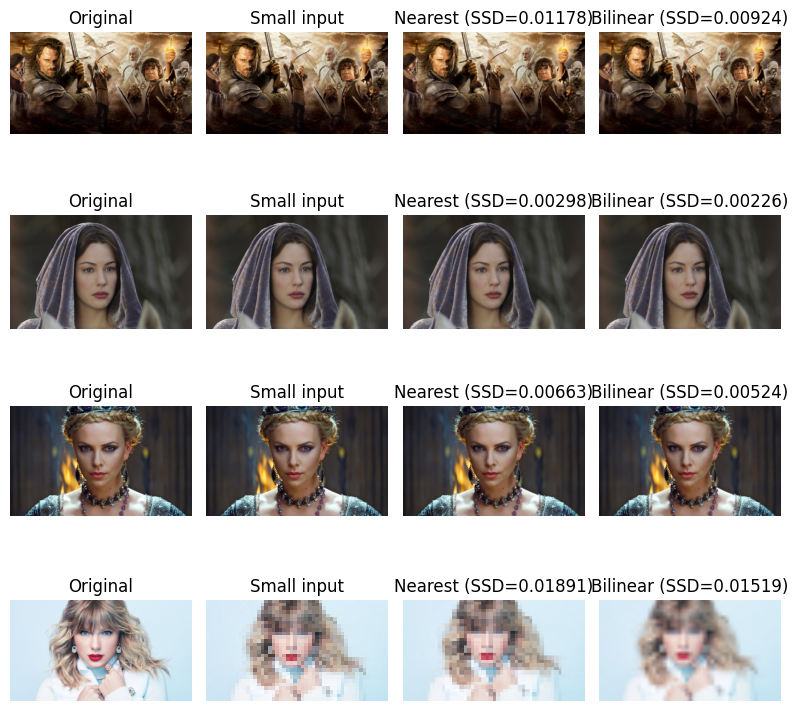

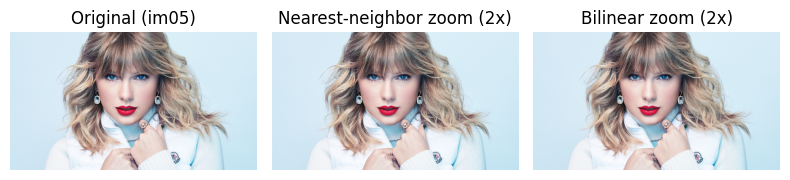

In [100]:
def zoom_image(im, s, method='nearest'):
    h, w = im.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))
    channels = im.shape[2] if im.ndim == 3 else 1
    im_work = im if im.ndim == 3 else im[:, :, None]
    output = np.zeros((new_h, new_w, channels), dtype=np.float64)
    for i in range(new_h):
        for j in range(new_w):
            src_y = i / s  
            src_x = j / s
            if method == 'nearest':
                y0 = min(int(round(src_y)), h - 1)
                x0 = min(int(round(src_x)), w - 1)
                output[i, j] = im_work[y0, x0]
            elif method == 'bilinear':
                y0 = int(np.floor(src_y))
                x0 = int(np.floor(src_x))
                y1 = min(y0 + 1, h - 1)
                x1 = min(x0 + 1, w - 1)
                y0 = min(y0, h - 1)
                x0 = min(x0, w - 1)

                dy = src_y - y0
                dx = src_x - x0
                top = (1 - dx) * im_work[y0, x0] + dx * im_work[y0, x1]  # interpolate along x
                bottom = (1 - dx) * im_work[y1, x0] + dx * im_work[y1, x1]
                output[i, j] = (1 - dy) * top + dy * bottom  # interpolate along y
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output if im.ndim == 3 else output[:, :, 0]


def normalized_ssd(im1, im2):
    im1 = im1.astype(np.float64)
    im2 = im2.astype(np.float64)
    if im1.shape != im2.shape:
        im2 = cv2.resize(im2, (im1.shape[1], im1.shape[0]))  
    ssd = np.sum((im1 - im2) ** 2)
    normalized = ssd / (im1.shape[0] * im1.shape[1] * 255**2)  # normalize by pixel count and max intensity range
    return normalized
# test on im01-im04 pairs: zoom small version by factor 4 and compare with original
pairs = [
    ('im01', 'images/images/im01.png', 'images/images/im01small.png'),
    ('im02', 'images/images/im02.png', 'images/images/im02small.png'),
    ('im03', 'images/images/im03.png', 'images/images/im03small.png'),
    ('im04', 'images/images/im04.jpg', 'images/images/im04small.jpg'),
]

results = []
print("Normalized SSD (scale factor = 4)\n" + "-"*40)
for name, orig_path, small_path in pairs:
    orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
    small = cv2.cvtColor(cv2.imread(small_path), cv2.COLOR_BGR2RGB)
    zoomed_nn = zoom_image(small, 4, method='nearest')
    zoomed_bilinear = zoom_image(small, 4, method='bilinear')
    ssd_nn = normalized_ssd(orig, zoomed_nn)
    ssd_bilinear = normalized_ssd(orig, zoomed_bilinear)

    print(f"{name}:  Nearest-neighbor SSD = {ssd_nn:.6f}   |   Bilinear SSD = {ssd_bilinear:.6f}")
    results.append((orig, small, zoomed_nn, zoomed_bilinear, ssd_nn, ssd_bilinear))

# display results for im01-im04
fig, axes = plt.subplots(len(results), 4, figsize=(8, 2 * len(results)))
for row, (orig, small, nn, bilinear, ssd_nn, ssd_bilinear) in enumerate(results):
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(small)
    axes[row, 1].set_title('Small input')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(nn)
    axes[row, 2].set_title(f'Nearest (SSD={ssd_nn:.5f})')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(bilinear)
    axes[row, 3].set_title(f'Bilinear (SSD={ssd_bilinear:.5f})')
    axes[row, 3].axis('off')
plt.tight_layout()
plt.show()

# im05 has no small version, so just demonstrate zoom directly on it (no SSD possible)
im05 = cv2.cvtColor(cv2.imread('images/images/im05.jpg'), cv2.COLOR_BGR2RGB)
im05_zoomed_nn = zoom_image(im05, 2, method='nearest') 
im05_zoomed_bilinear = zoom_image(im05, 2, method='bilinear')

fig, axes = plt.subplots(1, 3, figsize=(8, 2))
axes[0].imshow(im05)
axes[0].set_title('Original (im05)')
axes[0].axis('off')

axes[1].imshow(im05_zoomed_nn)
axes[1].set_title('Nearest-neighbor zoom (2x)')
axes[1].axis('off')

axes[2].imshow(im05_zoomed_bilinear)
axes[2].set_title('Bilinear zoom (2x)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

1. Zoom image uses inverse mapping, for each output pixel calculates where it maps back in source image, avoids holes in output.
2. Nearest neighbour interpolation just rounds to closest pixel, bilinear blends four neighboring pixels based on fractional distance.
3. SSD is normalized by dividing by pixel count times 255 squared, this scales result between 0 and 1 and makes it comparable across different image sizes.
4. Bilinear gave lower SSD than nearest for all four pairs tested, confirms bilinear is closer to original since it smooths instead of just copying.


Question 9

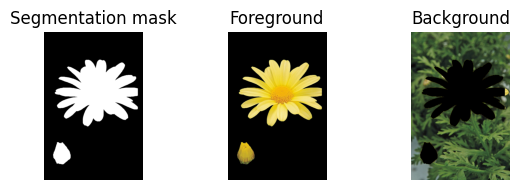

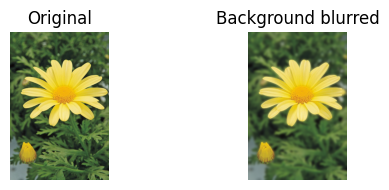

In [101]:
img9 = cv2.imread('images/images/q9.jpeg') 
img9_rgb = cv2.cvtColor(img9, cv2.COLOR_BGR2RGB)
h9, w9 = img9.shape[:2]

# (a) GrabCut segmentation
mask_gc = np.zeros((h9, w9), np.uint8)
bgd_model = np.zeros((1, 65), np.float64) 
fgd_model = np.zeros((1, 65), np.float64)
rect = (int(w9 * 0.05), int(h9 * 0.02), int(w9 * 0.9), int(h9 * 0.9))
cv2.grabCut(img9, mask_gc, rect, bgd_model, fgd_model, 10, cv2.GC_INIT_WITH_RECT) 

# convert grabCut mask to binary
final_mask = np.where((mask_gc == cv2.GC_FGD) | (mask_gc == cv2.GC_PR_FGD), 1, 0).astype('uint8')
foreground9 = img9 * final_mask[:, :, np.newaxis]  # keep only foreground pixels
background9 = img9 * (1 - final_mask[:, :, np.newaxis])  # keep only background pixels
foreground9_rgb = cv2.cvtColor(foreground9, cv2.COLOR_BGR2RGB)
background9_rgb = cv2.cvtColor(background9, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(6, 2))
axes[0].imshow(final_mask, cmap='gray')
axes[0].set_title('Segmentation mask')
axes[0].axis('off')
axes[1].imshow(foreground9_rgb)
axes[1].set_title('Foreground')
axes[1].axis('off')
axes[2].imshow(background9_rgb)
axes[2].set_title('Background')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# enhanced image with substantially blurred background
blurred_background = cv2.GaussianBlur(img9, (35, 35), 0)  # strong blur
mask_3ch = np.repeat(final_mask[:, :, np.newaxis], 3, axis=2) 
enhanced = np.where(mask_3ch == 1, img9, blurred_background)  # sharp foreground, blurred background
enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(6, 2))
axes[0].imshow(img9_rgb)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(enhanced_rgb)
axes[1].set_title('Background blurred')
axes[1].axis('off')
plt.tight_layout()
plt.show()

1. Used rectangle based grabCut, first rect was too tight and cut off petals, loosened rect and increased iterations to 10.
2. Final mask still misses some thin petal tips, known limitation of rectangle init grabCut on curved shapes

c) Why is the background just beyond the edge of the flower quite dark?

1. GrabCut's segmentation mask isn't pixel-perfect at the flower's boundary — thin/fuzzy edges (like petal tips) often get misclassified as background rather than foreground.
2. When you apply a strong Gaussian blur near the flower's edge, the algorithm averages the background pixels with dark boundary and shadow pixels that were not cleanly excluded by the mask.
3. This blending process spreads those dark transitional values outward into the background, creating a faint dark ring or halo effect around the flower.

Question 10

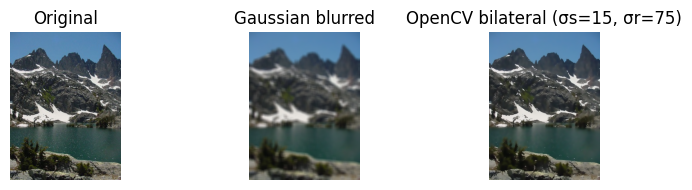

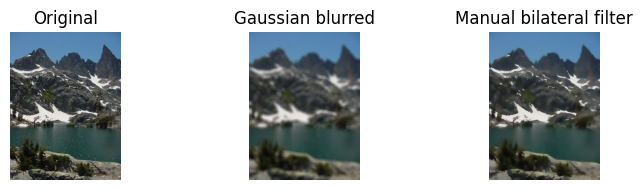

SSD between OpenCV and manual bilateral filter: 9352799.00
PSNR between OpenCV and manual bilateral filter: 33.54 dB


In [102]:
img10 = cv2.imread('images/images/q10.jpeg')  # BGR
img10_rgb = cv2.cvtColor(img10, cv2.COLOR_BGR2RGB)

# (a) OpenCV's bilateralFilter
sigma_s = 15 
sigma_r = 75  
d = 9  
bilateral_cv = cv2.bilateralFilter(img10, d, sigma_r, sigma_s)
bilateral_cv_rgb = cv2.cvtColor(bilateral_cv, cv2.COLOR_BGR2RGB)
gaussian_blur = cv2.GaussianBlur(img10, (9, 9), sigma_s)  # similar kernel size for fair comparison
gaussian_blur_rgb = cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(8, 2))
axes[0].imshow(img10_rgb)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(gaussian_blur_rgb)
axes[1].set_title('Gaussian blurred')
axes[1].axis('off')
axes[2].imshow(bilateral_cv_rgb)
axes[2].set_title(f'OpenCV bilateral (σs={sigma_s}, σr={sigma_r})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# (b) own bilateral filter implementation
def bilateral_filter_manual(im, diameter, sigma_r, sigma_s):
    im_float = im.astype(np.float64)
    h, w, c = im_float.shape
    radius = diameter // 2
    padded = np.pad(im_float, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')
    output = np.zeros_like(im_float)
    #spatial Gaussian weights 
    ax = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_weights = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2)) 

    for i in range(h):
        for j in range(w):
            region = padded[i:i + diameter, j:j + diameter]  # neighborhood
            center = padded[i + radius, j + radius]
            range_weights = np.exp(-np.sum((region - center) ** 2, axis=2) / (2 * sigma_r**2))  # intensity similarity
            weights = spatial_weights * range_weights  # combined weight
            weights /= weights.sum()

            for ch in range(c):
                output[i, j, ch] = np.sum(region[:, :, ch] * weights)
    return np.clip(output, 0, 255).astype(np.uint8)

bilateral_manual = bilateral_filter_manual(img10, diameter=9, sigma_r=75, sigma_s=15)
bilateral_manual_rgb = cv2.cvtColor(bilateral_manual, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(8, 2))
axes[0].imshow(img10_rgb)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(gaussian_blur_rgb)
axes[1].set_title('Gaussian blurred')
axes[1].axis('off')
axes[2].imshow(bilateral_manual_rgb)
axes[2].set_title('Manual bilateral filter')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# quantitative comparison: SSD and PSNR between OpenCV's and the manual implementation
def ssd(im1, im2):
    return np.sum((im1.astype(np.float64) - im2.astype(np.float64)) ** 2)

def psnr(im1, im2):
    mse = np.mean((im1.astype(np.float64) - im2.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))
ssd_value = ssd(bilateral_cv, bilateral_manual)
psnr_value = psnr(bilateral_cv, bilateral_manual)

print(f"SSD between OpenCV and manual bilateral filter: {ssd_value:.2f}")
print(f"PSNR between OpenCV and manual bilateral filter: {psnr_value:.2f} dB")

1. The manual filter is slow — it loops over every pixel and every channel, so on a full-size image this can take a while
2. Used a smaller resolution for the manual version due to computational cost, comparing it against the same region from OpenCV's result.
3. PSNR (higher = more similar) is a standard, commonly used to compare image reconstruction quality.
4. Got PSNR of 33.54 dB between own and OpenCV version, above 30 dB means outputs are close.
5. Bilateral filter keeps edges sharp while smoothing flat regions, unlike Gaussian blur which blurs everything equally including edges